# Stock forecast review

Reads `data/stocks/4_forecast/stock_prices_forecast.csv` — a single table for every ticker (see the `ticker` column), written by `pipelines/stock_forecast_pipeline.py`. It holds **both** the historical prices and the Chronos forecast, distinguished by the `record_type` column (`"history"` / `"forecast"`).

Run `pangolin run stock_forecast_pipeline` at least once before running this notebook (from the project root, with the virtualenv from `requirements.txt` active).

In [7]:
import os
from pathlib import Path

# pangolin resolves config/data_structure.yaml and .env relative to the
# current working directory (BASEPATH defaults to "."), but Jupyter starts
# notebooks with cwd = notebooks/ — move up to the project root first.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: c:\Users\GalluzziLorenzo\OneDrive - XTEL\Desktop\RobaLore\Repositories\pangolin-example


In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from pangolin.engine.DataFacility import get_project_data
from pangolin.config.settings import get_settings

D = get_project_data()
S = get_settings()

# "4_forecast" starts with a digit, so it isn't reachable as D.stocks.4_forecast
# (that's not valid Python attribute syntax) — get_node() takes the dotted
# path as a string instead, exactly for cases like this.
forecast_node = D.get_node("stocks.4_forecast")
print(forecast_node)

In [ ]:
# One combined table, every ticker (see the 'ticker' column) — written in a
# single node.write() by chronos_forecaster.py, so there's a single read
# here too, no per-ticker files to loop over.
#
# schema_overrides is needed: history rows sort first, and by default
# pl.read_csv infers each column's type from only the first 100 rows — all
# history, where forecast_low/forecast_high are empty — so it would infer
# those two columns as strings instead of floats.
SCHEMA_OVERRIDES = {
    "ticker": pl.Utf8,
    "open": pl.Float64,
    "high": pl.Float64,
    "low": pl.Float64,
    "close": pl.Float64,
    "volume": pl.Int64,
    "daily_return_pct": pl.Float64,
    "record_type": pl.Utf8,
    "forecast_low": pl.Float64,
    "forecast_high": pl.Float64,
}

all_data = forecast_node.read(try_parse_dates=True, schema_overrides=SCHEMA_OVERRIDES)
all_data.sort(["ticker", "date"])

## Row counts per ticker, by record_type

In [10]:
(
    all_data
    .group_by(["ticker", "record_type"])
    .agg(pl.len().alias("rows"), pl.col("date").min().alias("from"), pl.col("date").max().alias("to"))
    .sort(["ticker", "record_type"])
)

ticker,record_type,rows,from,to
str,str,u32,date,date
"""AAPL""","""forecast""",100,2026-09-04,2027-01-21
"""AAPL""","""history""",1255,2021-09-03,2026-09-03
"""AMZN""","""forecast""",100,2026-09-04,2027-01-21
"""AMZN""","""history""",1255,2021-09-03,2026-09-03
"""MSFT""","""forecast""",100,2026-09-04,2027-01-21
"""MSFT""","""history""",1255,2021-09-03,2026-09-03


## Daily return % (custom/transformers.py: add_daily_return_pct)

In [ ]:
(
    all_data
    .filter(pl.col("record_type") == "history")
    .group_by("ticker")
    .agg(
        pl.col("daily_return_pct").mean().round(3).alias("mean_%"),
        pl.col("daily_return_pct").std().round(3).alias("std_%"),
        pl.col("daily_return_pct").min().round(2).alias("worst_day_%"),
        pl.col("daily_return_pct").max().round(2).alias("best_day_%"),
    )
    .sort("ticker")
)

## History vs. forecast, per ticker

Solid line = actual close price. Dashed line = Chronos forecast median. Shaded band = 10th–90th percentile forecast interval (`forecast_low` / `forecast_high`).

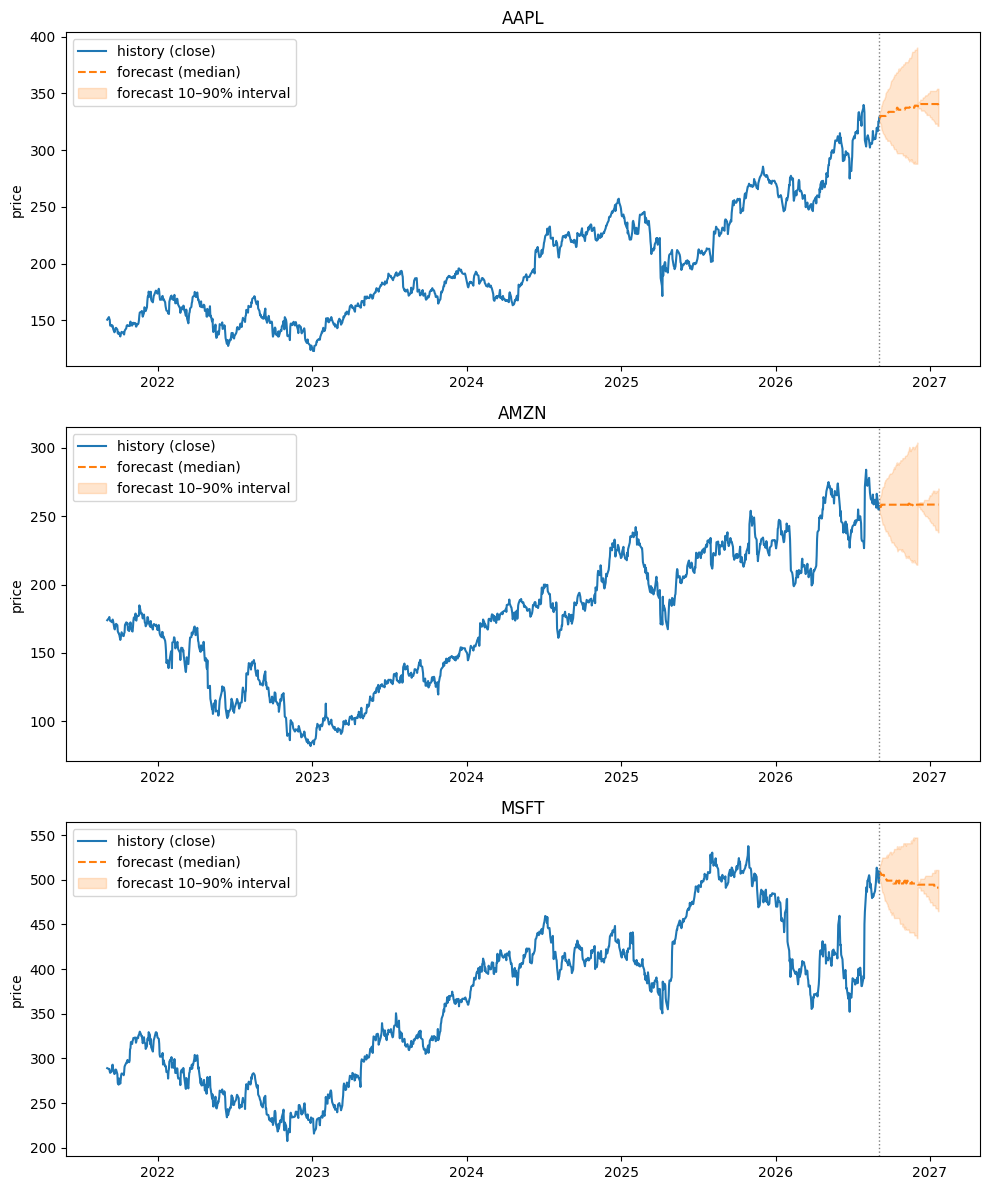

In [11]:
tickers = all_data["ticker"].unique().sort().to_list()

fig, axes = plt.subplots(len(tickers), 1, figsize=(10, 4 * len(tickers)), squeeze=False)

for ax, ticker in zip(axes[:, 0], tickers):
    df = all_data.filter(pl.col("ticker") == ticker).sort("date")
    history = df.filter(pl.col("record_type") == "history")
    forecast = df.filter(pl.col("record_type") == "forecast")

    ax.plot(history["date"], history["close"], label="history (close)", color="tab:blue")
    if len(forecast) > 0:
        ax.plot(forecast["date"], forecast["close"], "--", label="forecast (median)", color="tab:orange")
        ax.fill_between(
            forecast["date"], forecast["forecast_low"], forecast["forecast_high"],
            color="tab:orange", alpha=0.2, label="forecast 10–90% interval",
        )
        ax.axvline(history["date"].max(), color="gray", linestyle=":", linewidth=1)

    ax.set_title(ticker)
    ax.set_ylabel("price")
    ax.legend()

fig.tight_layout()
plt.show()

## Last close vs. forecast horizon end

In [12]:
rows = []
for ticker in tickers:
    df = all_data.filter(pl.col("ticker") == ticker).sort("date")
    last_history = df.filter(pl.col("record_type") == "history").tail(1)
    last_forecast = df.filter(pl.col("record_type") == "forecast").tail(1)
    if len(last_history) == 0 or len(last_forecast) == 0:
        continue
    last_close = last_history["close"][0]
    horizon_close = last_forecast["close"][0]
    rows.append({
        "ticker": ticker,
        "last_actual_date": last_history["date"][0],
        "last_actual_close": last_close,
        "forecast_horizon_date": last_forecast["date"][0],
        "forecast_horizon_close": horizon_close,
        "change_pct": round(100 * (horizon_close - last_close) / last_close, 2),
    })

pl.DataFrame(rows)

ticker,last_actual_date,last_actual_close,forecast_horizon_date,forecast_horizon_close,change_pct
str,date,f64,date,f64,f64
"""AAPL""",2026-09-03,328.700012,2027-01-21,338.677826,3.04
"""AMZN""",2026-09-03,257.359985,2027-01-21,258.530487,0.45
"""MSFT""",2026-09-03,509.179993,2027-01-21,491.216797,-3.53
